# Week 1 – Strategic Planning and Data Exploration in Logistics

**Name:** Dharmana Lokesh  
**Role:** Logistics Data Analyst Intern

## Project: Delivery Performance Analysis

The aim of this Week 1 work is to plan a simple logistics data analysis project.  
I will use delivery records to understand delivery time, delays, distance and transportation cost.


## 1. Project Definition

A logistics company delivers orders to different locations using vans and trucks. Some orders are delivered on time, while some are delayed.

The company wants to understand its delivery performance using data.

For this project, I will study:

- delivery time
- delivery delays
- delivery distance
- transportation cost
- vehicle type

The analysis can help the company understand where delivery performance can be improved.


## 2. Project Objectives

1. Understand the delivery data.
2. Calculate important logistics KPIs.
3. Find simple patterns in delivery performance.
4. Understand how Python can be used for logistics analysis.
5. Plan how regression, clustering and optimization can be used later.


## 3. KPIs

I will use these KPIs:

- **On-Time Delivery Rate:** percentage of orders delivered on time.
- **Delivery Delay Rate:** percentage of orders that were delayed.
- **Average Delivery Time:** average time taken to deliver an order.
- **Average Transportation Cost:** average cost for one delivery.
- **Average Distance:** average distance travelled per delivery.


## 4. Data Research

For background research, I referred to the World Bank Logistics Performance Index and the DataCo Global Supply Chain dataset available through Kaggle.

The World Bank LPI provides information about logistics performance and delivery timeliness. The DataCo dataset is a public supply-chain dataset that can be used for late-delivery analysis.

For this first-week notebook, I prepared a small CSV file with 50 delivery records so that the analysis can be demonstrated clearly. The CSV contains basic fields needed for the selected KPIs.


## 5. Load the CSV File

The CSV file contains 50 sample delivery records.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("logistics data 1.csv")

df.head()


,Order_ID,Destination,Distance_KM,Delivery_Time_Hours,Transport_Cost,Vehicle_Type,Delivery_Status
0,1001,Vijayawada,60,7.7,540,Van,Delayed
1,1002,Warangal,22,2.4,272,Mini Truck,On Time
2,1003,Guntur,12,1.8,108,Van,On Time
3,1004,Warangal,55,5.5,525,Van,On Time
4,1005,Vijayawada,25,3.3,305,Truck,On Time


## 6. Check the Data

In [3]:
print("Number of records:", len(df))
print("Number of columns:", len(df.columns))

df.info()


Number of records: 50
Number of columns: 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_ID             50 non-null     int64  
 1   Destination          50 non-null     object 
 2   Distance_KM          50 non-null     int64  
 3   Delivery_Time_Hours  50 non-null     float64
 4   Transport_Cost       50 non-null     int64  
 5   Vehicle_Type         50 non-null     object 
 6   Delivery_Status      50 non-null     object 
dtypes: float64(1), int64(3), object(3)
memory usage: 2.9+ KB


## 7. Check Missing Values

In [4]:
df.isnull().sum()


Order_ID               0
Destination            0
Distance_KM            0
Delivery_Time_Hours    0
Transport_Cost         0
Vehicle_Type           0
Delivery_Status        0
dtype: int64

## 8. Calculate the KPIs

In [5]:
total_orders = len(df)

on_time = (df["Delivery_Status"] == "On Time").sum()
delayed = (df["Delivery_Status"] == "Delayed").sum()

on_time_rate = (on_time / total_orders) * 100
delay_rate = (delayed / total_orders) * 100

average_delivery_time = df["Delivery_Time_Hours"].mean()
average_cost = df["Transport_Cost"].mean()
average_distance = df["Distance_KM"].mean()

print("On-Time Delivery Rate:", round(on_time_rate, 2), "%")
print("Delivery Delay Rate:", round(delay_rate, 2), "%")
print("Average Delivery Time:", round(average_delivery_time, 2), "hours")
print("Average Transportation Cost:", round(average_cost, 2))
print("Average Distance:", round(average_distance, 2), "KM")


On-Time Delivery Rate: 70.0 %
Delivery Delay Rate: 30.0 %
Average Delivery Time: 4.25 hours
Average Transportation Cost: 391.38
Average Distance: 35.62 KM


## 9. Simple Data Exploration

I will compare delivery performance for different vehicle types.

In [6]:
vehicle_summary = df.groupby("Vehicle_Type")[[
    "Distance_KM",
    "Delivery_Time_Hours",
    "Transport_Cost"
]].mean()

vehicle_summary


,Distance_KM,Delivery_Time_Hours,Transport_Cost
Vehicle_Type,,,
Mini Truck,35.529412,4.235294,402.000000
Truck,35.571429,4.300000,466.714286
Van,35.736842,4.221053,326.368421


## 10. Check Delivery Status

Delivery_Status
On Time    35
Delayed    15
Name: count, dtype: int64


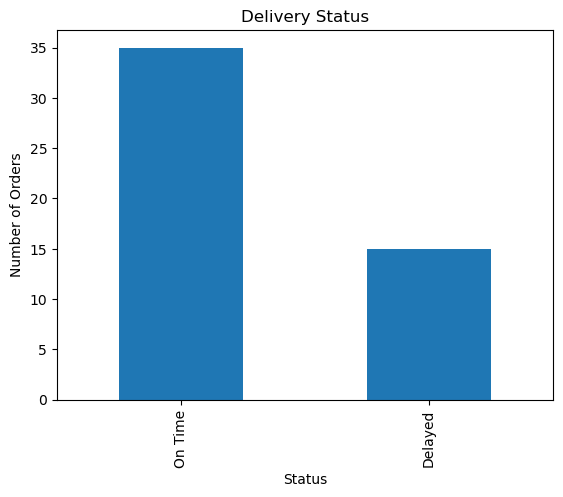

In [7]:
print(df["Delivery_Status"].value_counts())

df["Delivery_Status"].value_counts().plot(kind="bar")
plt.title("Delivery Status")
plt.xlabel("Status")
plt.ylabel("Number of Orders")
plt.show()


## 11. Distance and Delivery Time

                     Distance_KM  Delivery_Time_Hours
Distance_KM             1.000000             0.930534
Delivery_Time_Hours     0.930534             1.000000


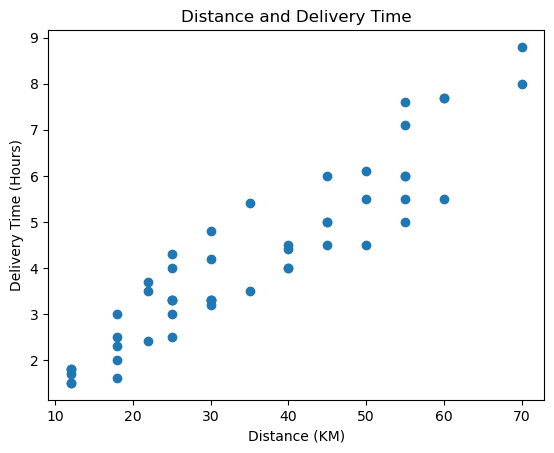

In [8]:
print(df[["Distance_KM", "Delivery_Time_Hours"]].corr())

plt.scatter(df["Distance_KM"], df["Delivery_Time_Hours"])
plt.title("Distance and Delivery Time")
plt.xlabel("Distance (KM)")
plt.ylabel("Delivery Time (Hours)")
plt.show()


## 12. How Data Science Can Be Used

### Regression
Regression can be used to predict a numerical value such as delivery time.

For example:

**Distance + other delivery information → predicted delivery time**

### Clustering
Clustering can be used to group similar deliveries or routes.

For example:

- short-distance deliveries
- medium-distance deliveries
- long-distance deliveries

### Optimization
Optimization can be used later to find better routes or allocate vehicles while considering constraints such as vehicle capacity and delivery requirements.


## 13. Python Example – Simple Regression

This is only an example of the proposed approach. It is not the final project model.

In [9]:
from sklearn.linear_model import LinearRegression

X = df[["Distance_KM"]]
y = df["Delivery_Time_Hours"]

model = LinearRegression()
model.fit(X, y)

prediction = model.predict([[40]])

print("Estimated delivery time for 40 KM:",
      round(prediction[0], 2), "hours")


Estimated delivery time for 40 KM: 4.71 hours


C:\Users\lokes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 14. Strategic Roadmap

The planned analysis process is:

**Data Collection → Data Cleaning → Exploratory Analysis → KPI Calculation → Predictive Analysis → Business Understanding**

### Data Collection
Use a suitable public logistics dataset.

### Data Cleaning
Check missing values, duplicates and incorrect data types.

### Exploratory Analysis
Study delivery time, distance, cost and delays.

### KPI Calculation
Calculate the selected logistics KPIs.

### Predictive Analysis
Later, test suitable models such as regression for delivery-time prediction.

### Business Understanding
Use the results to understand delivery performance and resource allocation.


## 15. Conclusion

In Week 1, I defined a logistics delivery problem and identified the main KPIs needed to measure performance.

I used a small CSV file to practise loading the data, checking the data and calculating the KPIs. I also explored the relationship between distance and delivery time.

For the next stage, the same process can be applied to a larger public logistics dataset. Regression, clustering and optimization can then be studied further based on the available data.
